In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy import text
import os

# Configuring visual defaults
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 10

# Move to project root 
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working directory:", os.getcwd())

load_dotenv() 

## Database Connection
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine =create_engine(f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

with engine.connect() as conn:
    result = conn.execute(text("select count(*) from fraud_dw.fact_transactions"))
    count = result.scalar()
    print(f"Connected to database. Fact_transactions has {count:,} rows.")


Working directory: d:\Innomatics\Git_Uploads\Credit-card-risk-analytics
Connected to database. Fact_transactions has 590,540 rows.


### Phase 01 -- Fraud landscape

**Business Questions** -- How big is the fraud pronlem and where is it concentrated ?

This notebook establishes the baseline fraud metrics -- overall rates, product breakdowns, card-network and card-type distributions, and amoub=nt distributions. These numbers are the foundation that every subsequent phase builds on.

**Source Data --** 590,540 transacrions, Dec 2017 - Jun 2018, from the IEEE - CIS fraud Detection dataset

**Techniques Showcased --** 'filter' clause, 'Percentile_cont', 'grouping sets'.
 

Each query from sql will be imported as a dataframe and data visualization will be done the get the insights from the query.

In [3]:
# -- 01. Overall fraud_rate by count and by transactional amount

query_1 ="""
select
		count(*) 												as tot_transactions,
		count(*) filter (where is_fraud is true)				as fraud_transactions,
		round(100 * count(*) filter (where is_fraud)
						/count(*),2)							as fraud_rate_count_pct,

		round(sum(transaction_amt),2)							as total_amount,
		round(sum(transaction_amt) filter(where is_fraud),2)	as fraud_amount,
		round(100 * sum(transaction_amt) filter(where is_fraud)
				/ sum(transaction_amt),2)						as fraud_rate_amount_pct
from fraud_dw.fact_transactions;
"""

df1 = pd.read_sql(query_1,engine)
df1

,tot_transactions,fraud_transactions,fraud_rate_count_pct,total_amount,fraud_amount,fraud_rate_amount_pct
0,590540,20663,3.0,79738980.37,3083847.67,3.87


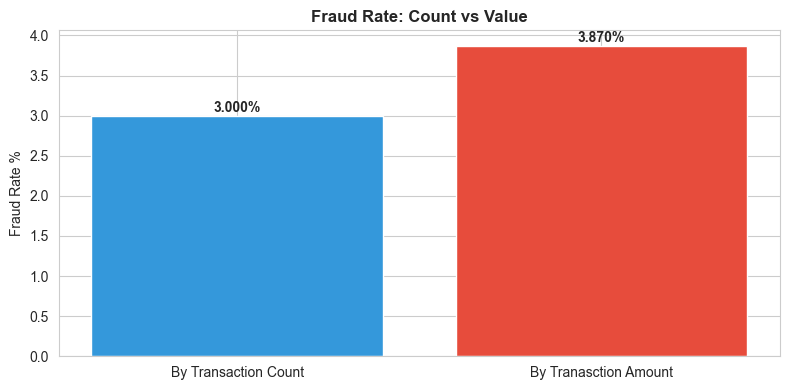

In [5]:
## Query 1 vis

fig, ax = plt.subplots(figsize =(8,4))

categories = ["By Transaction Count", "By Tranasction Amount"]
rates = [df1["fraud_rate_count_pct"].iloc[0],df1["fraud_rate_amount_pct"].iloc[0]]

bars = ax.bar(categories,rates,color = ['#3498db', '#e74c3c'])
ax.set_ylabel("Fraud Rate %")
ax.set_title('Fraud Rate: Count vs Value', fontsize=12, fontweight='bold')

for bar, rate in zip(bars,rates):
    ax.text(bar.get_x()+ bar.get_width()/2, bar.get_height() + 0.05,
            f'{rate:.3f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("visuals/phase1_q1_fraud_rate_overview.png", bbox_inches='tight')
plt.show()

### Insight 1: Fraud is rare but value-heavy

- **3% of all transactions are fraudulent** — about 1 in every 29 transactions.
- **Fraud accounts for 3.87% of total transaction amount** — replace with your actual result.
- If the value rate exceeds the count rate, fraudsters target higher-value transactions. 
  This is what we'd expect: organized fraud rings prefer high-ticket targets.

**Implication:** A fraud detection system needs to optimize for value caught, not 
just transaction count. Catching 100 small-dollar attacks is less valuable than 
catching 10 large-dollar ones.

In [2]:
# -- fraud_rate by product category

query_2 ="""
select 
		p.product_category,
		count(*) 										as txn_count,
		count(*) filter (where f.is_fraud)				as fraud_count,
		round(100 * count(*) filter (where f.is_fraud)	
						/count(*),2)					as fraud_rate_pct,
						
		round(sum(f.transaction_amt),2)							as total_amount,
		round(sum(f.transaction_amt) filter(where is_fraud),2)	as fraud_amount
from fraud_dw.fact_transactions f
left join fraud_dw.dim_product p
on f.product_id = p.product_id
group by p.product_category
order by fraud_rate_pct desc;
"""
df2 = pd.read_sql(query_2,engine)
df2



,product_category,txn_count,fraud_count,fraud_rate_pct,total_amount,fraud_amount
0,Card-Not-Present,68519,8008,11.0,2937602.40,391424.21
1,Subscription,11628,686,5.0,700813.60,43416.00
2,Hotel/Travel,33024,1574,4.0,2416368.00,246632.00
3,Retail,37699,1426,3.0,6344975.00,348050.00
4,Web Purchase,439670,8969,2.0,67339221.37,2054325.46


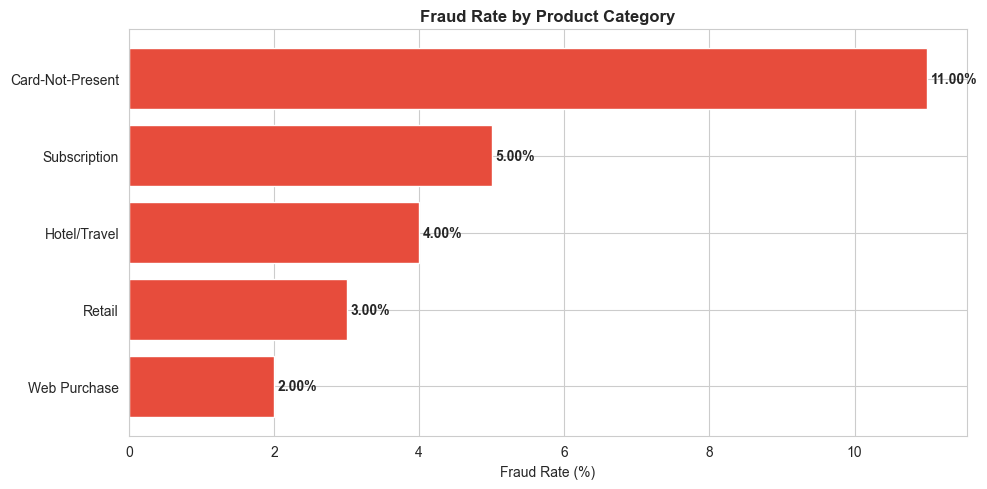

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(df2['product_category'], df2['fraud_rate_pct'], color='#e74c3c')
ax.set_xlabel('Fraud Rate (%)')
ax.set_title('Fraud Rate by Product Category', fontsize=12, fontweight='bold')
ax.invert_yaxis()  # highest at top

# Add value labels
for bar, rate in zip(bars, df2['fraud_rate_pct']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{rate:.2f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('visuals/phase1_q2_fraud_by_product.png', bbox_inches='tight')
plt.show()

### Insight 2: Card-Not-Present and Web Purchase dominate fraud

- The product category with the highest fraud rate is **Card Not Present**.
- This aligns with industry knowledge: physical-card-required transactions (Retail, Hotel/Travel) 
  have lower fraud because the attacker needs the actual card.
- **Card-Not-Present (CNP)** transactions are inherently riskier — fraudsters only need 
  the card number, not the physical card.

**Implication:** Risk teams should apply tighter rules to CNP and Web Purchase categories. 
Step-up authentication (3DS, OTP) is justified for these channels.